# FEATURE PREPROCESSING


**Load the dataset again**

In [5]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/carclaims.csv")

print("Dataset shape:", df.shape)

Dataset shape: (15420, 33)


**Repeat cleaning**

In [6]:
# Handle invalid values

df["Age"] = df["Age"].replace(0, np.nan)

df["DayOfWeekClaimed"] = df["DayOfWeekClaimed"].replace("0", np.nan)

df["MonthClaimed"] = df["MonthClaimed"].replace("0", np.nan)

# Remove identifier
df = df.drop(columns=["PolicyNumber"], errors="ignore")

# Create target
df["FraudFlag"] = df["FraudFound"].map({
    "No": 0,
    "Yes": 1
})

print("Cleaned dataset shape:", df.shape)

Cleaned dataset shape: (15420, 33)


**Create X and y**

In [7]:
X = df.drop(columns=["FraudFound", "FraudFlag"])

y = df["FraudFlag"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (15420, 31)
y shape: (15420,)


**Split the data**

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (12336, 31)
Testing data: (3084, 31)


**Identify feature types**

In [9]:
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:", numeric_features)
print("\nNumber of numerical features:", len(numeric_features))

print("\nCategorical features:", categorical_features)
print("\nNumber of categorical features:", len(categorical_features))

Numerical features: ['WeekOfMonth', 'WeekOfMonthClaimed', 'Age', 'RepNumber', 'Deductible', 'DriverRating', 'Year']

Number of numerical features: 7

Categorical features: ['Month', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed', 'Sex', 'MaritalStatus', 'Fault', 'PolicyType', 'VehicleCategory', 'VehiclePrice', 'Days:Policy-Accident', 'Days:Policy-Claim', 'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType', 'NumberOfSuppliments', 'AddressChange-Claim', 'NumberOfCars', 'BasePolicy']

Number of categorical features: 24


**Create the preprocessing pipeline**

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


**LOGISTIC REGRESSION**

In [11]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        ))
    ]
)

print("Logistic Regression pipeline created successfully.")

Logistic Regression pipeline created successfully.


**Train**

In [12]:
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**Fix the convergence warning**

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            class_weight="balanced",
            max_iter=3000,
            solver="liblinear",
            random_state=42
        ))
    ]
)

print("Logistic Regression pipeline created successfully.")

Logistic Regression pipeline created successfully.


**Train**

In [14]:
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


**evaluate the model**

In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

Accuracy : 0.6433
Precision: 0.1325
Recall   : 0.8919
F1 Score : 0.2308
ROC-AUC  : 0.8058


In [16]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Not Fraud", "Fraud"]
))

              precision    recall  f1-score   support

   Not Fraud       0.99      0.63      0.77      2899
       Fraud       0.13      0.89      0.23       185

    accuracy                           0.64      3084
   macro avg       0.56      0.76      0.50      3084
weighted avg       0.94      0.64      0.74      3084



# RANDOM FOREST

In [17]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

print("Random Forest pipeline created successfully.")

Random Forest pipeline created successfully.


**TRAIN**

In [18]:
random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


**PREDICT**

In [19]:
rf_pred = random_forest_model.predict(X_test)
rf_prob = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest predictions completed.")

Random Forest predictions completed.


**EVALUATE**

In [20]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_prob)

print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_roc_auc, 4))

Accuracy : 0.9407
Precision: 1.0
Recall   : 0.0108
F1 Score : 0.0214
ROC-AUC  : 0.8355


In [21]:
print(classification_report(
    y_test,
    rf_pred,
    target_names=["Not Fraud", "Fraud"]
))

              precision    recall  f1-score   support

   Not Fraud       0.94      1.00      0.97      2899
       Fraud       1.00      0.01      0.02       185

    accuracy                           0.94      3084
   macro avg       0.97      0.51      0.50      3084
weighted avg       0.94      0.94      0.91      3084



In [22]:
rf_pred = random_forest_model.predict(X_test)

rf_prob = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest probabilities generated successfully.")

Random Forest probabilities generated successfully.


# **threshold analysis**

In [23]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.50, 0.40, 0.30, 0.20, 0.10, 0.05]

for threshold in thresholds:
    rf_threshold_pred = (rf_prob >= threshold).astype(int)

    precision = precision_score(
        y_test,
        rf_threshold_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        rf_threshold_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        rf_threshold_pred,
        zero_division=0
    )

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.4f} | "
        f"Recall: {recall:.4f} | "
        f"F1: {f1:.4f}"
    )

Threshold: 0.50 | Precision: 1.0000 | Recall: 0.0108 | F1: 0.0214
Threshold: 0.40 | Precision: 0.8750 | Recall: 0.0378 | F1: 0.0725
Threshold: 0.30 | Precision: 0.4400 | Recall: 0.0595 | F1: 0.1048
Threshold: 0.20 | Precision: 0.2703 | Recall: 0.2162 | F1: 0.2402
Threshold: 0.10 | Precision: 0.1656 | Recall: 0.7081 | F1: 0.2684
Threshold: 0.05 | Precision: 0.1285 | Recall: 0.9405 | F1: 0.2261


# GRADIENT BOOSTING

In [24]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline

gradient_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]
)

print("Gradient Boosting pipeline created successfully.")

Gradient Boosting pipeline created successfully.


**TRAIN**

In [25]:
gradient_model.fit(X_train, y_train)

print("Gradient Boosting model trained successfully.")

Gradient Boosting model trained successfully.


**GENERATE PREDICTION**

In [26]:
gb_pred = gradient_model.predict(X_test)
gb_prob = gradient_model.predict_proba(X_test)[:, 1]

print("Gradient Boosting predictions completed.")

Gradient Boosting predictions completed.


**EVALUATE**

In [27]:
gb_accuracy = accuracy_score(y_test, gb_pred)
gb_precision = precision_score(y_test, gb_pred, zero_division=0)
gb_recall = recall_score(y_test, gb_pred, zero_division=0)
gb_f1 = f1_score(y_test, gb_pred, zero_division=0)
gb_roc_auc = roc_auc_score(y_test, gb_prob)

print("Accuracy :", round(gb_accuracy, 4))
print("Precision:", round(gb_precision, 4))
print("Recall   :", round(gb_recall, 4))
print("F1 Score :", round(gb_f1, 4))
print("ROC-AUC  :", round(gb_roc_auc, 4))

Accuracy : 0.941
Precision: 0.7143
Recall   : 0.027
F1 Score : 0.0521
ROC-AUC  : 0.8445


In [28]:
print(classification_report(
    y_test,
    gb_pred,
    target_names=["Not Fraud", "Fraud"]
))

              precision    recall  f1-score   support

   Not Fraud       0.94      1.00      0.97      2899
       Fraud       0.71      0.03      0.05       185

    accuracy                           0.94      3084
   macro avg       0.83      0.51      0.51      3084
weighted avg       0.93      0.94      0.91      3084



# Gradient Boosting Threshold Analysis

In [29]:
thresholds = [0.50, 0.40, 0.30, 0.20, 0.10, 0.05]

for threshold in thresholds:
    gb_threshold_pred = (gb_prob >= threshold).astype(int)

    precision = precision_score(
        y_test,
        gb_threshold_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        gb_threshold_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        gb_threshold_pred,
        zero_division=0
    )

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.4f} | "
        f"Recall: {recall:.4f} | "
        f"F1: {f1:.4f}"
    )

Threshold: 0.50 | Precision: 0.7143 | Recall: 0.0270 | F1: 0.0521
Threshold: 0.40 | Precision: 0.6667 | Recall: 0.0324 | F1: 0.0619
Threshold: 0.30 | Precision: 0.6111 | Recall: 0.0595 | F1: 0.1084
Threshold: 0.20 | Precision: 0.2667 | Recall: 0.1514 | F1: 0.1931
Threshold: 0.10 | Precision: 0.1746 | Recall: 0.7297 | F1: 0.2818
Threshold: 0.05 | Precision: 0.1309 | Recall: 0.9676 | F1: 0.2307


# Precision-Recall Curve

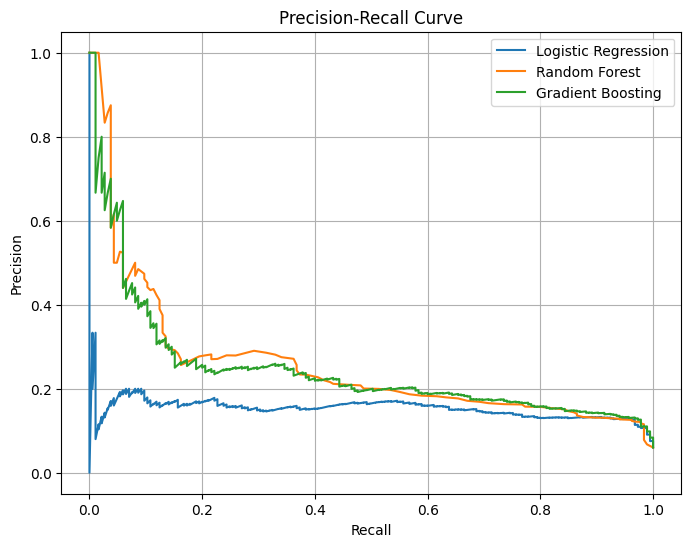

In [30]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Logistic Regression
lr_precision, lr_recall, _ = precision_recall_curve(
    y_test,
    y_prob
)

# Random Forest
rf_precision, rf_recall, _ = precision_recall_curve(
    y_test,
    rf_prob
)

# Gradient Boosting
gb_precision, gb_recall, _ = precision_recall_curve(
    y_test,
    gb_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    lr_recall,
    lr_precision,
    label="Logistic Regression"
)

plt.plot(
    rf_recall,
    rf_precision,
    label="Random Forest"
)

plt.plot(
    gb_recall,
    gb_precision,
    label="Gradient Boosting"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid()

plt.show()

# Confusion Matrix

Confusion Matrix:
[[2261  638]
 [  50  135]]


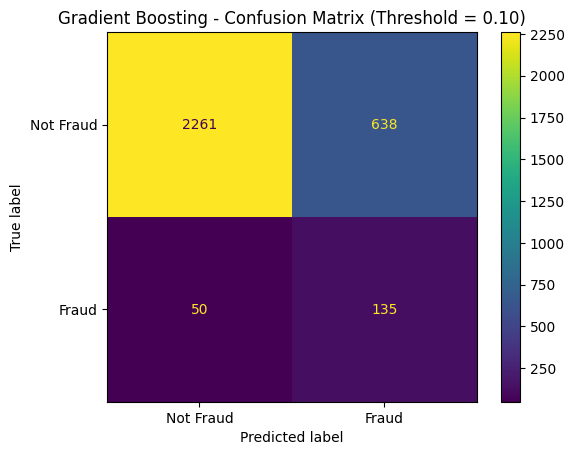

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Apply selected threshold
gb_final_pred = (gb_prob >= 0.10).astype(int)

# Create confusion matrix
cm = confusion_matrix(y_test, gb_final_pred)

print("Confusion Matrix:")
print(cm)

# Display
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Fraud", "Fraud"]
)

disp.plot()
plt.title("Gradient Boosting - Confusion Matrix (Threshold = 0.10)")
plt.show()

# Feature Importance

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# Get the trained Gradient Boosting classifier
gb_classifier = gradient_model.named_steps["classifier"]

# Get feature names after preprocessing
feature_names = gradient_model.named_steps["preprocessor"].get_feature_names_out()

# Get feature importance
importance = gb_classifier.feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display top 15 features
print(feature_importance.head(15))

                                     Feature  Importance
133    cat__AddressChange-Claim_2 to 3 years    0.170183
144                cat__BasePolicy_Liability    0.159628
72                  cat__Fault_Policy Holder    0.148249
73                    cat__Fault_Third Party    0.096942
2                                   num__Age    0.052454
75         cat__PolicyType_Sedan - Collision    0.045103
6                                  num__Year    0.044566
136  cat__AddressChange-Claim_under 6 months    0.016623
78         cat__PolicyType_Sport - Collision    0.016247
26                          cat__Make_Accura    0.015163
107                cat__AgeOfVehicle_4 years    0.013137
3                             num__RepNumber    0.011484
63                     cat__MonthClaimed_Nov    0.011415
4                            num__Deductible    0.008919
142               cat__BasePolicy_All Perils    0.008646


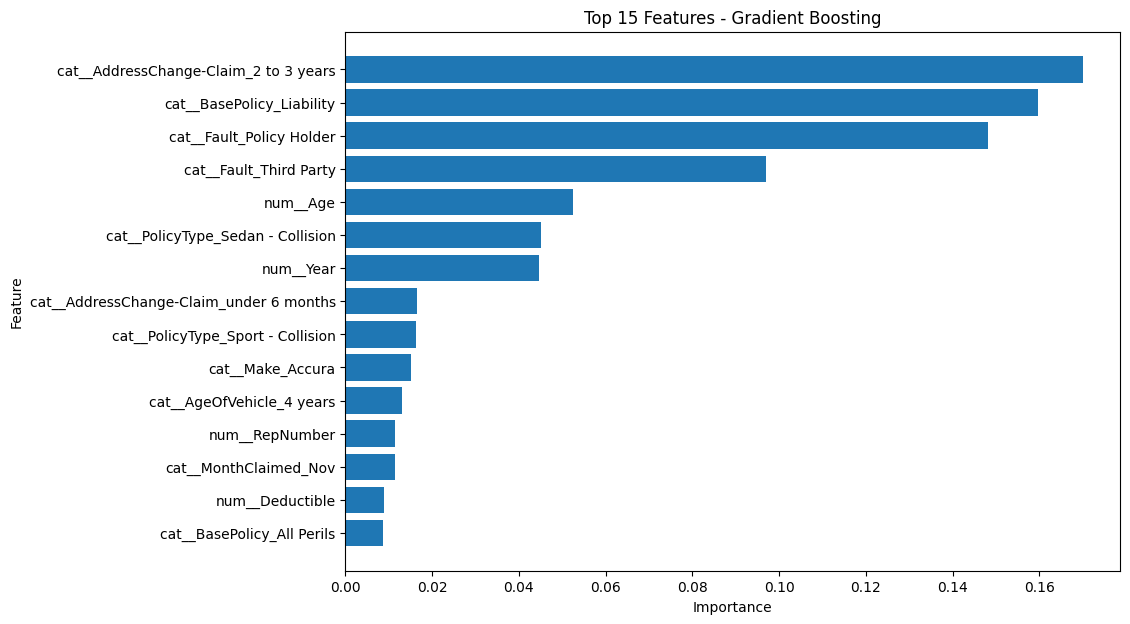

In [33]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features - Gradient Boosting")

plt.show()

# Final Model Evaluation

In [34]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Final threshold
final_threshold = 0.10

# Final predictions
final_pred = (gb_prob >= final_threshold).astype(int)

# Metrics
final_accuracy = accuracy_score(y_test, final_pred)
final_precision = precision_score(y_test, final_pred, zero_division=0)
final_recall = recall_score(y_test, final_pred, zero_division=0)
final_f1 = f1_score(y_test, final_pred, zero_division=0)
final_roc_auc = roc_auc_score(y_test, gb_prob)

print("FINAL GRADIENT BOOSTING MODEL")
print("=" * 40)
print("Threshold :", final_threshold)
print("Accuracy  :", round(final_accuracy, 4))
print("Precision :", round(final_precision, 4))
print("Recall    :", round(final_recall, 4))
print("F1 Score  :", round(final_f1, 4))
print("ROC-AUC   :", round(final_roc_auc, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    final_pred,
    target_names=["Not Fraud", "Fraud"]
))

FINAL GRADIENT BOOSTING MODEL
Threshold : 0.1
Accuracy  : 0.7769
Precision : 0.1746
Recall    : 0.7297
F1 Score  : 0.2818
ROC-AUC   : 0.8445

Classification Report:
              precision    recall  f1-score   support

   Not Fraud       0.98      0.78      0.87      2899
       Fraud       0.17      0.73      0.28       185

    accuracy                           0.78      3084
   macro avg       0.58      0.75      0.57      3084
weighted avg       0.93      0.78      0.83      3084



**Save Final Model**

In [36]:
print("gb_model exists:", "gb_model" in globals())
print("gb_prob exists:", "gb_prob" in globals())
print("preprocessor exists:", "preprocessor" in globals())
print("X_train exists:", "X_train" in globals())
print("y_train exists:", "y_train" in globals())

gb_model exists: False
gb_prob exists: True
preprocessor exists: True
X_train exists: True
y_train exists: True


In [37]:

[x for x in globals().keys() if 'gb' in x.lower() or 'gradient' in x.lower()]

['GradientBoostingClassifier',
 'gradient_model',
 'gb_pred',
 'gb_prob',
 'gb_accuracy',
 'gb_precision',
 'gb_recall',
 'gb_f1',
 'gb_roc_auc',
 'gb_threshold_pred',
 'gb_final_pred',
 'gb_classifier']

In [42]:
import joblib

joblib.dump(
    gradient_model,
    "insurance_fraud_gradient_boosting.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [39]:
import os

print(os.path.exists("insurance_fraud_gradient_boosting.pkl"))

True


# Predict the claim

In [46]:
import joblib

loaded_model = joblib.load("insurance_fraud_gradient_boosting.pkl")

print("Saved model loaded successfully!")

Saved model loaded successfully!


In [45]:
new_claim = pd.DataFrame([{
    "Month": "Jan",
    "WeekOfMonth": 2,
    "DayOfWeek": "Monday",
    "Make": "Honda",
    "AccidentArea": "Urban",
    "DayOfWeekClaimed": "Tuesday",
    "MonthClaimed": "Jan",
    "WeekOfMonthClaimed": 2,
    "Sex": "Male",
    "MaritalStatus": "Single",
    "Age": 30,
    "Fault": "Policy Holder",
    "PolicyType": "Sedan - Collision",
    "VehicleCategory": "Sedan",
    "VehiclePrice": "20,000 to 29,000",
    "RepNumber": 10,
    "Deductible": 400,
    "DriverRating": 3,
    "Days:Policy-Accident": "8 to 15",
    "Days:Policy-Claim": "8 to 15",
    "PastNumberOfClaims": "none",
    "AgeOfVehicle": "3 years",
    "AgeOfPolicyHolder": "26 to 30",
    "PoliceReportFiled": "No",
    "WitnessPresent": "No",
    "AgentType": "External",
    "NumberOfSuppliments": "none",
    "AddressChange-Claim": "2 to 3 years",
    "NumberOfCars": "1 vehicle",
    "Year": 1995,
    "BasePolicy": "Liability"
}])

print("New claim created successfully!")
print("Shape:", new_claim.shape)

New claim created successfully!
Shape: (1, 31)


In [47]:
fraud_probability = loaded_model.predict_proba(new_claim)[:, 1][0]

threshold = 0.10
prediction = int(fraud_probability >= threshold)

print("Fraud Probability:", round(fraud_probability, 4))
print("Threshold:", threshold)

if prediction == 1:
    print("Prediction: POTENTIAL FRAUD")
else:
    print("Prediction: NOT FRAUD")

Fraud Probability: 0.0142
Threshold: 0.1
Prediction: NOT FRAUD


# Final Model Comparison

In [48]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Threshold": [
        0.50,
        0.10,
        0.10
    ],
    "Accuracy": [
        0.6433,
        None,
        0.7769
    ],
    "Precision": [
        0.1325,
        0.1656,
        0.1746
    ],
    "Recall": [
        0.8919,
        0.7081,
        0.7297
    ],
    "F1 Score": [
        0.2308,
        0.2684,
        0.2818
    ],
    "ROC-AUC": [
        0.8058,
        0.8355,
        0.8445
    ]
})

comparison

,Model,Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.5,0.6433,0.1325,0.8919,0.2308,0.8058
1,Random Forest,0.1,NaN,0.1656,0.7081,0.2684,0.8355
2,Gradient Boosting,0.1,0.7769,0.1746,0.7297,0.2818,0.8445


calculate the correct Random Forest accuracy at threshold 0.10

In [49]:
rf_final_pred = (rf_prob >= 0.10).astype(int)

rf_final_accuracy = accuracy_score(
    y_test,
    rf_final_pred
)

print("Random Forest Accuracy at threshold 0.10:",
      round(rf_final_accuracy, 4))

Random Forest Accuracy at threshold 0.10: 0.7685


In [50]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Threshold": [
        0.50,
        0.10,
        0.10
    ],
    "Accuracy": [
        0.6433,
        rf_final_accuracy,
        0.7769
    ],
    "Precision": [
        0.1325,
        0.1656,
        0.1746
    ],
    "Recall": [
        0.8919,
        0.7081,
        0.7297
    ],
    "F1 Score": [
        0.2308,
        0.2684,
        0.2818
    ],
    "ROC-AUC": [
        0.8058,
        0.8355,
        0.8445
    ]
})

comparison

,Model,Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.5,0.643300,0.1325,0.8919,0.2308,0.8058
1,Random Forest,0.1,0.768482,0.1656,0.7081,0.2684,0.8355
2,Gradient Boosting,0.1,0.776900,0.1746,0.7297,0.2818,0.8445


# ROC Curve

In [52]:
# Generate prediction probabilities for all three models

lr_prob = logistic_model.predict_proba(X_test)[:, 1]

rf_prob = random_forest_model.predict_proba(X_test)[:, 1]

# gb_prob already exists, so we don't need to recreate it

print("Prediction probabilities generated successfully!")

Prediction probabilities generated successfully!


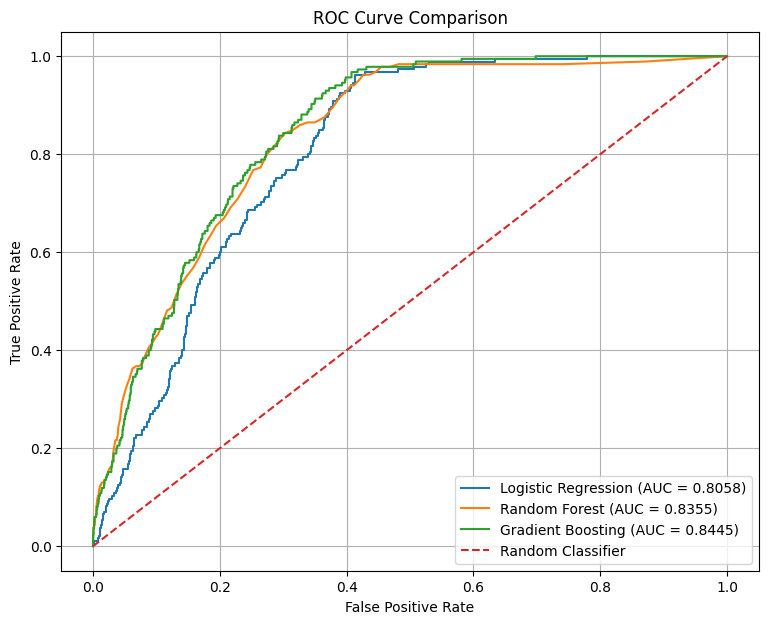

In [53]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_prob)

plt.figure(figsize=(9, 7))

plt.plot(
    lr_fpr, lr_tpr,
    label="Logistic Regression (AUC = 0.8058)"
)

plt.plot(
    rf_fpr, rf_tpr,
    label="Random Forest (AUC = 0.8355)"
)

plt.plot(
    gb_fpr, gb_tpr,
    label="Gradient Boosting (AUC = 0.8445)"
)

plt.plot(
    [0, 1], [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()

plt.show()

# **Final Project Conclusion**

This project developed a machine learning-based automobile insurance fraud detection system using a dataset containing 15,420 insurance claims and 33 features. The dataset was analyzed through exploratory data analysis, data cleaning, preprocessing, and class-imbalance analysis. Since only 5.99% of the claims were fraudulent, accuracy alone was not considered sufficient for evaluating the models.

Three classification algorithms were implemented and compared: Logistic Regression, Random Forest, and Gradient Boosting. Threshold tuning was performed to improve the detection of fraudulent claims. Based on the overall performance, Gradient Boosting was selected as the final model with a threshold of 0.10.

The final Gradient Boosting model achieved:
Accuracy: 77.69%
Precision: 17.46%
Recall: 72.97%
F1 Score: 28.18%
ROC-AUC: 84.45%

The model successfully identified a large proportion of fraudulent claims, which is particularly important in fraud detection where missing fraudulent claims can be costly. The feature-importance analysis also highlighted variables such as AddressChange-Claim, BasePolicy, Fault, Age, and PolicyType among the most influential features for the Gradient Boosting model.

Overall, the project demonstrates that machine learning can be used to identify potentially fraudulent automobile insurance claims and support insurance companies in prioritizing claims for further investigation. The model should be considered a decision-support tool rather than a replacement for human investigation, and future improvements could focus on better handling of class imbalance, hyperparameter tuning, probability calibration, and testing on newer real-world insurance data.

**Final Model**

Gradient Boosting — Threshold = 0.10

Final takeaway: The model prioritizes detecting fraudulent claims rather than maximizing accuracy, making it more suitable for an insurance fraud-screening application where identifying suspicious claims is the primary objective.

# FUTURE IMPROVEMENTS
 Future improvements include better handling of class imbalance, hyperparameter optimization, advanced boosting algorithms, improved feature engineering, business-driven threshold optimization, and explainable AI techniques such as SHAP. Testing the model on newer real-world insurance data would also help evaluate its generalization and practical effectiveness.

In [54]:
from google.colab import files

files.download("insurance_fraud_gradient_boosting.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>